#  Deep Learning for Natural Language Processing - Exercise 2
## Author: Margarita Orfanidi ID: 7115152400023
The definition of ambiguity in the responses politicians give during interviews is a very challenging task in the field of NLP. Based on the dataset released for SemEval 2026 Task 6 (CLARITY), this assignment tries to explore this NLP problem by fine-tuning Transformer-based architectures. Specifically, this notebook explores the implementation and performance of the BERT model.

## Load libraries and dataset

In [1]:
#!pip install transformers datasets torch scikit-learn sentencepiece tqdm \
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install contractions pyspellchecker

import random
import sys
import time
sys.path.append('/kaggle/input/datasets/leloulv/utils-exercise-2')
sys.path.append('/kaggle/input/datasets/leloulv/exercise1-nlp')
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler,DataCollatorWithPadding
from transformers import  logging
from tqdm.auto import tqdm
from datasets import load_dataset
from torch.optim import AdamW
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from torch.utils.data import  WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from utils import *
from helper_functions import *
from preprocessing_fucntions import *
set_seed(seed=42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 16.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.3 MB/s eta 0:00:00


In [2]:
# Load the dataset (train and test sets)
dataset = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

# Exploratory Data Analysis
As a first step, it is important to explore the dataset in depth in order to better understand the nature and characteristics of the problem we aim to address. Our task is a classification problem focused on response clarity. Specifically, the goal is to classify political responses into predefined categories that reflect the level of clarity or evasiveness present in an answer.

Before proceeding to the modeling stage, it is necessary to perform an initial inspection of the dataset. This exploratory step allows us to examine basic statistics, understand the distribution of the labels, and identify potential patterns that appear in the data. Through this process, we can confirm the structure of the dataset, recognize the most important variables, and develop a clearer understanding of the problem we are attempting to solve.

## Metadata Analysis

This step helps verify that both train and test sets share the same structure (i.e., they contain the same columns) and allows us to inspect important properties such as the presence of missing values, data types, and the overall size of the datasets (number of entries) before further processing.

In [3]:
display(df_train.info())
display(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3448 entries, 0 to 3447
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  3448 non-null   object
 1   date                   3448 non-null   object
 2   president              3448 non-null   object
 3   url                    3448 non-null   object
 4   question_order         3448 non-null   int64 
 5   interview_question     3448 non-null   object
 6   interview_answer       3448 non-null   object
 7   gpt3.5_summary         3448 non-null   object
 8   gpt3.5_prediction      3448 non-null   object
 9   question               3448 non-null   object
 10  annotator_id           3448 non-null   object
 11  annotator1             0 non-null      object
 12  annotator2             0 non-null      object
 13  annotator3             0 non-null      object
 14  inaudible              3448 non-null   bool  
 15  multiple_questions   

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  0 non-null      object
 1   date                   0 non-null      object
 2   president              0 non-null      object
 3   url                    308 non-null    object
 4   question_order         308 non-null    int64 
 5   interview_question     308 non-null    object
 6   interview_answer       308 non-null    object
 7   gpt3.5_summary         0 non-null      object
 8   gpt3.5_prediction      0 non-null      object
 9   question               308 non-null    object
 10  annotator_id           0 non-null      object
 11  annotator1             308 non-null    object
 12  annotator2             308 non-null    object
 13  annotator3             308 non-null    object
 14  inaudible              308 non-null    bool  
 15  multiple_questions     

None

### Sample display
We displayed random samples from the dataset in order to observe the structure and formatting of the textual data. This qualitative inspection helps identify potential patterns and understand how the text appears in practice, allowing us to draw conclusions about the preprocessing steps that may be required. For example, we observed several spelling inconsistencies and cases where punctuation marks are not properly separated from words due to missing spaces.

In [4]:
# Display random samples of the training set
display_samples(df_train,1)

Sample 2900


,Value
title,"The President's News Conference With President Lee Myung-bak of South Korea at Camp David, Maryland"
date,"April 19, 2008"
president,George W. Bush
url,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-lee-myung-bak-south-korea-camp-david
question_order,2
interview_question,"Q. I have a question for President Lee. Korea and the United States have made many achievements through the summit meeting, especially North Korean nuclear issue and the strengthening of the alliance. As for North Korean nuclear issue, Mr. President Lee suggested setting up a permanent liaison office in both Seoul and Pyongyang. What are some of the follow-up effects, if you do have any follow-up actions? And do you have any thoughts of proposing a meeting with Chairman Kim at an earlier date?"
interview_answer,"The process is not something that we discussed between ourselves during the summit meeting. In fact, when I was staying in Washington, DC, I had an interview with one of the newspapers there, and it came up. Of course, it was not a sudden suggestion. I did have a meeting among my staff and related ministries, and I talked about this in detail before I came to the United States.We have a new administration in Korea, and we haven't yet to begun dialogue with the ns. Inter-Korean dialogue, there is a need for us to have dialogue all the time. Up until now, we had dialogues whenever the need arose, and then it would stop. However, dialogue should be based on genuine cooperation and sincerity. And so with this in mind, I thought that it would be helpful to set up a permanent liaison office in both Seoul and Pyongyang.As for the summit meeting between myself and Chairman Kim, I will agree to it when the need is real. And I already said publicly that I am willing to meet with him—not just once, but many times—but if the meeting will yield substantial and real results. I believe only when that is possible, I am ready to meet with him and have sincere dialogue, because that will help to bring about peace and stability of the peninsula.So basically, I do hold that thought, but I'm not suggesting that—to have a meeting with Chairman Kim anytime soon. If the need arises, again, I'm ready to meet with him. Steven Lee [Steven Lee Myers, New York Times]."
gpt3.5_summary,"The question consists of 2 parts:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue.\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date.\n\n<--Summary Answer-->\n\nThe response provides the following information regarding these points:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue:\n- President Lee suggests setting up a permanent liaison office in both Seoul and Pyongyang to facilitate dialogue and cooperation between North Korea and South Korea.\n- The suggestion was made during an interview with a newspaper in Washington, DC, and was not discussed during the summit meeting.\n- The intention behind the suggestion is to establish genuine cooperation and sincerity in inter-Korean dialogue.\n\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date:\n- President Lee is open to the idea of a meeting with Chairman Kim, but only when the need is real and there is a possibility of substantial and real results.\n- He believes that sincere dialogue with Chairman Kim can contribute to the peace and stability of the Korean peninsula.\n- While he holds the thought of meeting with Chairman Kim, he is not suggesting a meeting anytime soon, but is willing to meet if the need arises.\n\nOverall, President Lee emphasizes the importance of genuine cooperation, sincerity, and substantial results in both the setup of a liaison office and the possibility of a meeting with Chairman Kim."
gpt3.5_prediction,"Question 1: Follow-up effects of setting up a permanent liaison office in Se

The responses are labeled based on whether they address each sub-question. As a result, the same response may appear multiple times in the dataset, depending on the number of sub-questions associated with a given interview question.

This behavior is illustrated below by displaying the original question, the corresponding sub-questions, the interview response, and the assigned label. As shown, the same response is repeated across different sub-questions, while the assigned label may vary depending on how well the response addresses each sub-question.

In [5]:
def show_question(df, interview_q):
    subset = df[df['interview_question'] == interview_q]

    print("INTERVIEW QUESTION:")
    print(interview_q)

    for i, row in subset.iterrows():
        print("\n--- Example ---")
        print("Sub-question:")
        print(row['question'])

        print("\nAnswer:")
        print(row['interview_answer'][:300] + "...") 

        print("\nClarity label:", row['clarity_label'])

q = random.choice(df_train['interview_question'].unique())
show_question(df_train, q)

INTERVIEW QUESTION:
Q. And if I could, on the election, sir—can I——TikTok/Microsoft Corporation  Q. President Trump, on the sale of TikTok, you're basically arguing that the U.S. Government is going to collect a cut from a—of a transaction including two companies, in which it doesn't hold a stake in.That's unprecedented. That's never happened in U.S. history before, and the administration has offered very little explanation about how that's going to work. Can you back your statement up and provide specifics about how that would work?

--- Example ---
Sub-question:
The interviewer's request for President Trump to back up his statement and provide specific details on how the government would collect this cut.

Answer:
Did you say, That's impressive? Did you actually use that term?...

Clarity label: Ambivalent

--- Example ---
Sub-question:
The previous comment made by the interviewer, expressing that President Trump is arguing for the U.S. Government to collect a cut from the sale of Ti

## Label Distribution
Clarity Labels Distribution
The labels used for the classification task are the clarity labels, which include Clear Reply, Clear Non-Reply, and Ambivalent. The distribution of instances across these labels is shown below. The majority of instances belong to the Ambivalent class, accounting for approximately 59.2\% of the data (2039 samples). The Clear Reply category represents about 30.5\% of the dataset (1051 samples), while Clear Non-Reply is the least frequent class with 10.3\% (356 samples). This distribution indicates a noticeable class imbalance, with the Ambivalent class dominating the dataset, a factor that should be considered during model training and evaluation.

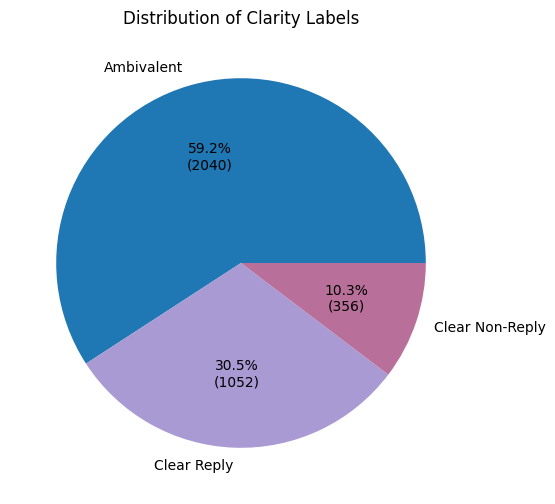

In [6]:
colors = ["#1f77b4", "#a99ad3", "#b8709a"]

df_train["clarity_label"].value_counts().plot(
    kind="pie",
    autopct=lambda p: f"{p:.1f}%\n({int(p*len(df_train)/100)})",
    figsize=(6,6),
    colors=colors
)
plt.title("Distribution of Clarity Labels")
plt.ylabel("")
plt.show()

#### Clarity Label Distribution by President
It is important to determine whether the nature of the responses in our dataset is speaker-dependent. By analyzing the distribution of clarity labels for each president, we aim to identify if the communication style—specifically the tendency toward directness or evasion—is influenced by the individual identity of the speaker rather than being a uniform characteristic of the overall data.As illustrated in the figures, Ambivalent responses constitute the majority for all presidents. However, some differences can be observed. In particular, Barack Obama exhibits the highest proportion of Ambivalent responses (68.1\%), indicating a larger share of indirect or partially evasive answers. In contrast, Donald J. Trump shows a higher proportion of Clear Reply responses (32.6\%), suggesting that he provides more direct answers compared to the other presidents. 
Nevertheless, as shown in the grouped bar chart, these differences remain relatively small, and no substantial variation is observed in the overall response patterns among the presidents. In other words, the distributions display a notable degree of uniformity.

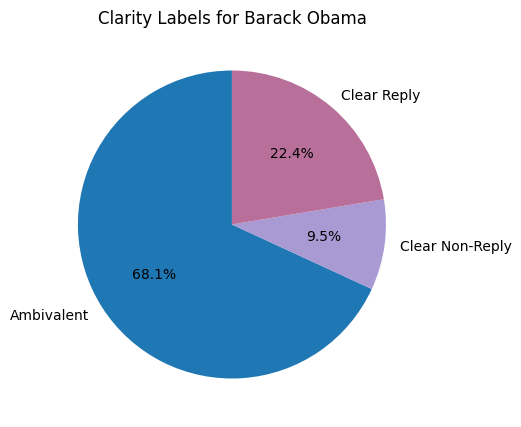

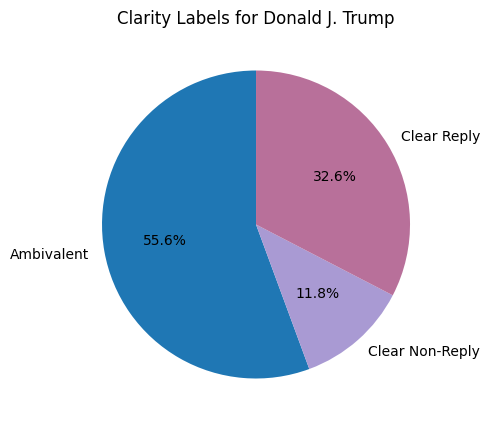

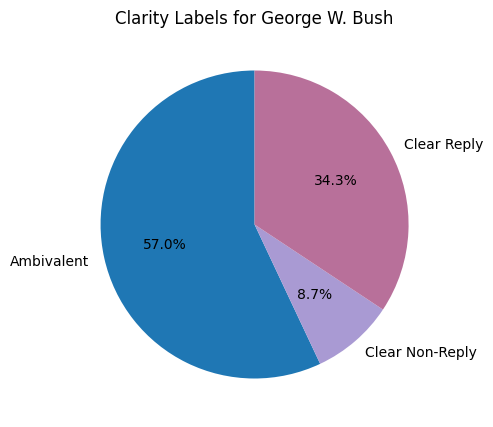

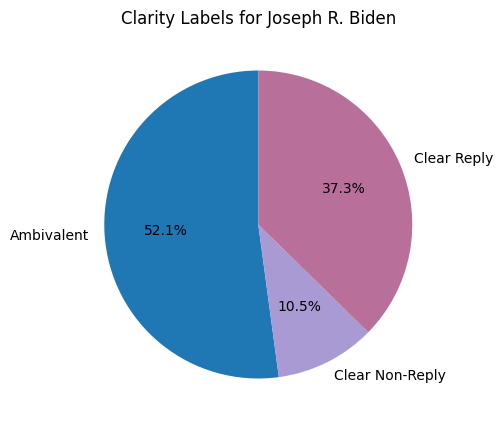

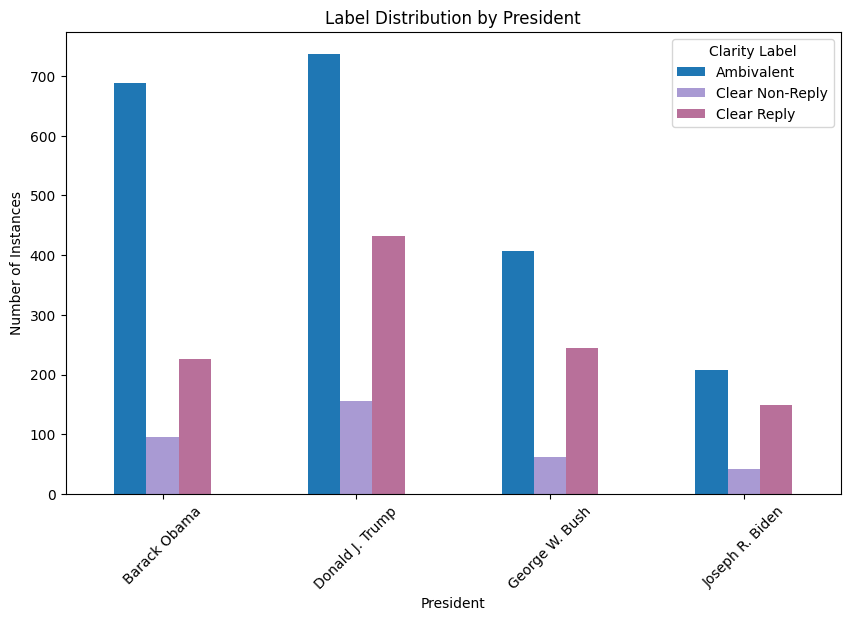

In [7]:
 plot_clarity_distribution_by_president(df_train)

In [8]:
 pd.crosstab(df_train["president"], df_train["clarity_label"], margins=True ,normalize="index")


clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
president,,,
Barack Obama,0.681188,0.095050,0.223762
Donald J. Trump,0.556226,0.117736,0.326038
George W. Bush,0.570028,0.086835,0.343137
Joseph R. Biden,0.521303,0.105263,0.373434
All,0.591647,0.103248,0.305104


#### Clarity Labels Distribution by Year
The distribution of clarity labels across different years. As observed, there is no significant temporal variation in the distribution, as the relative proportions of the labels remain stable over time.

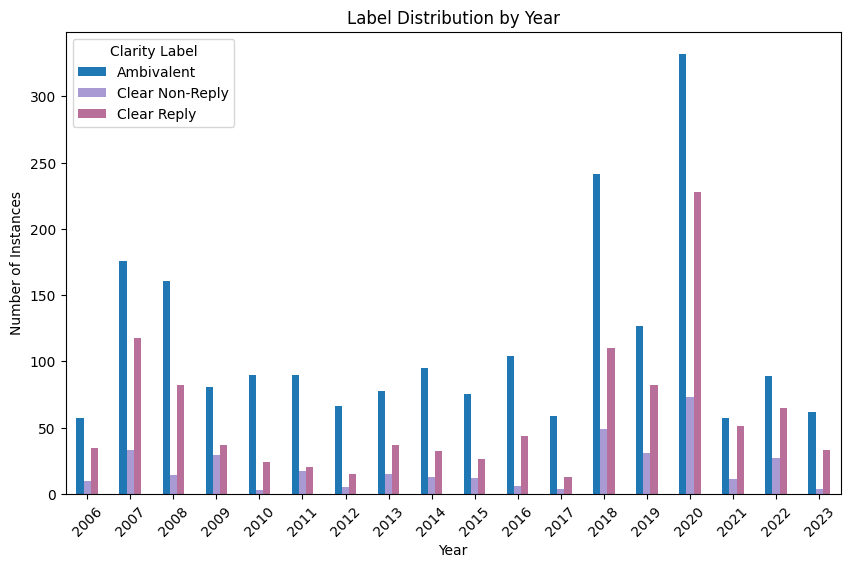

In [9]:
df_train["date"] = pd.to_datetime(df_train["date"])
df_train["year"] = df_train["date"].dt.year
label_by_president = df_train.groupby(["year","clarity_label"]).size().unstack()

colors = ["#1f77b4", "#a99ad3", "#b8709a"]
label_by_president.plot(
    kind="bar",
    stacked=False,
    figsize=(10,6),
    color=colors
)

plt.title("Label Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Instances")
plt.legend(title="Clarity Label")
plt.xticks(rotation=45)

plt.show()

#### Clarity Labels Distribution by Affirmative 
Affirmative questions are associated with a modest shift toward more decisive responses—both clear replies and clear non-replies—and a corresponding decrease in ambivalence. Specifically, when affirmative questions are present, the proportion of Ambivalent responses drops (from 60.5\% to 54.5\%), while both Clear Reply (from 29.9\% to 32.6\%) and Clear Non-Reply responses (from 9.6\% to 12.8\%) increase.

This pattern suggests that such questions may encourage the interviewee to respond more directly. However, the magnitude of these differences remains relatively small, indicating that while the effect is consistent, it is not particularly strong.

In [10]:
pd.crosstab(df_train["affirmative_questions"], df_train["clarity_label"], normalize="index")

clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
affirmative_questions,,,
False,0.605007,0.096039,0.298954
True,0.545337,0.128238,0.326425


## Textual Analysis

### Clarity Label Distribution by Word Count

 The dataset contains 3,448 responses, with an average length of approximately 294 words and a high standard deviation (301.54), indicating substantial variability in response length. The distribution is highly skewed, ranging from very short answers (1 word) to very long ones (up to 2,117 words). The median value (207 words) is lower than the mean, suggesting the presence of long outlier responses that increase the average.
 
 Examining the classes separately, Ambivalent responses not only constitute the majority of the dataset (2,040 samples) but also tend to be longer on average (331.86 words) and exhibit the highest variability (standard deviation of 319.53). Clear Reply responses include 1,052 samples with a moderate average length of 272.04 words and a relatively high spread (standard deviation of 269.54). In contrast, Clear Non-Reply responses form the smallest group (356 samples) and are considerably shorter, with an average length of 137.81 words and lower variability (standard deviation of 217.39).

Overall, these results indicate a clear relationship between response length and clarity. Shorter responses are more frequently associated with non-replies, while longer and more variable responses tend to correspond to ambivalent answers. This observation suggests that response length may serve as a useful feature for distinguishing between clarity categories.

In [3]:
train = df_train[["question", "interview_answer", "clarity_label"]].copy()
train["text"] = ( train["question"] + " " + train["interview_answer"])

test = df_test[["question", "interview_answer", "clarity_label"]].copy()
test ["text"] = ( test["question"] + " " + test["interview_answer"] ) 

### Detection of Text Patterns in the Dataset
Only numerical patterns were detected in the dataset. Since no strong or meaningful textual patterns were identified, no additional preprocessing is required.

In [16]:
detect_text_patterns(train["text"])


Starting dataset inspection...
----------------------------------------
Clean: No HTML Tags found.

Clean: No Emails found.

Clean: No URLs (http/www) found.

Clean: No Twitter Mentions (@) found.

Clean: No Hashtags (#) found.

Found: 1527 texts with Digits.
Clean: No Newlines (\n) found.

Clean: No Emojis found.

----------------------------------------
Inspection completed!


### Detection of spelling errors
Spelling errors constitute a very small portion of the dataset (approximately 1.96\% of all words), suggesting that the textual data is generally clean and that spelling mistakes are unlikely to significantly affect the performance of the classification models.

In [17]:
check_spelling_errors(train["text"])
find_bad_samples(train["text"], threshold=30)

Total words: 1125356
Misspelled words: 22040
Percentage of misspelled words: 1.96%
Example misspelled words: ['thei', 'chineseno', 'aboutit', 've', 'donei']


In [18]:
check_spelling_errors(test["text"])
find_bad_samples(test["text"], threshold=30)

Total words: 110842
Misspelled words: 1591
Percentage of misspelled words: 1.44%
Example misspelled words: ['corke', 'nbc', 'll', 'hu', 'jintao']


## Token Analysis 

Since BERT has a strict architectural limitation of 512 tokens per sequence, it is critical to evaluate the token distribution produced by the BERT tokenizer on this dataset. The analysis shows a mean length of 397.24 tokens and a median of 291.0. While the majority of samples fall within BERT’s capacity, a significant 29.41% of the dataset exceeds the 512-token limit. Because nearly one-third of the sequences are subject to truncation, there is a substantial risk of losing key information.



In [4]:
# 1. Suppress warnings to maintain a clean output console
logging.set_verbosity_error()

# Define the model checkpoint and initialize the corresponding tokenizer
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def count_tokens(question, answer, tokenizer):
    # Encode the question and answer pair into input IDs
    # truncation=False: Ensures the text is not cut off, allowing an accurate count of all tokens
    # add_special_tokens=True: Includes model-specific tokens like [CLS] and [SEP]
    tokens = tokenizer.encode(
        question, 
        answer, 
        add_special_tokens=True, 
        truncation=False 
    )
    return len(tokens)

# Calculate token counts for all question-answer pairs in the training set
token_counts = [count_tokens(q, a, tokenizer) for q, a in zip(df_train["question"], df_train["interview_answer"])]
token_counts = np.array(token_counts)

# Restore the default logging level to see important warnings again
logging.set_verbosity_warning()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [5]:
# Display basic token statistics
print(f"Total samples: {len(token_counts)}")
print(f"Mean length: {token_counts.mean():.2f}")
print(f"Median length: {np.median(token_counts)}")
print(f"Maximum length: {token_counts.max()}")
print(f"Minimum length: {token_counts.min()}")

# Identify how many samples exceed the BERT limit (512 tokens)
# This helps determine if information will be lost during truncation.
over_limit = (token_counts > 512).sum()
percentage = (over_limit / len(token_counts)) * 100

print(f"\nSamples exceeding 512 tokens: {over_limit} ({percentage:.2f}%)")

Total samples: 3448
Mean length: 397.24
Median length: 291.0
Maximum length: 2595
Minimum length: 7

Samples exceeding 512 tokens: 1014 (29.41%)


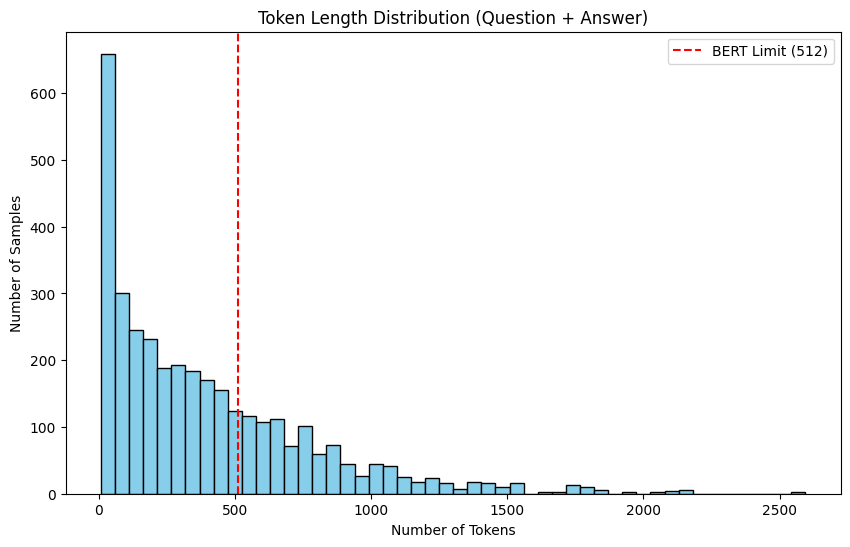

In [6]:
plt.figure(figsize=(10, 6))

# Plot the histogram of token counts
plt.hist(token_counts, bins=50, color='skyblue', edgecolor='black')

# Add a vertical dashed line to indicate the BERT maximum sequence length
plt.axvline(x=512, color='red', linestyle='--', label='BERT Limit (512)')

# Set plot labels and title
plt.title('Token Length Distribution (Question + Answer)')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Samples')

# Display the legend to identify the 512-limit line
plt.legend()

plt.show()

# Preprocessing

Before training, a few simple preprocessing steps were applied. First, the question and interview_answer columns in both the training and test sets were explicitly cast to string type to prevent any type-related errors during tokenization. Second, any duplicate rows, based on a combination of the question, interview_answer, and clarity_label columns, were removed from the training set, ensuring that no identical question-answer-label triplets appeared more than once. Finally, the categorical clarity_label column was mapped to numeric integer labels — Clear Reply as 0, Ambivalent as 1, and Clear Non-Reply as 2 — as PyTorch requires class labels to be represented as integers rather than strings when computing loss during training.

Additional cleaning steps, such as stop word removal, were also explored but ultimately discarded, as they did not yield any noticeable improvement and risked stripping semantically relevant content from the interview responses.

In [4]:


#  text columns
df_train["question"] = df_train["question"].astype(str)
df_train["interview_answer"] = df_train["interview_answer"].astype(str)

df_test["question"] = df_test["question"].astype(str)
df_test["interview_answer"] = df_test["interview_answer"].astype(str)


# size before removing duplicates
print("Before drop_duplicates:", df_train.shape)

# remove duplicated rows based on question + answer + label
df_train = df_train.drop_duplicates(subset=["question", "interview_answer", "clarity_label"])

# size after removing duplicates
print("After drop_duplicates:", df_train.shape)


Before drop_duplicates: (3448, 20)
After drop_duplicates: (3402, 20)


In [5]:


print("Original labels:", df_train['clarity_label'].unique())

label_mapping = {
    "Clear Reply": 0,
    "Ambivalent": 1,
    "Clear Non-Reply": 2
}
# Apply the mapping to both train and test dataframes
df_train['labels'] = df_train['clarity_label'].map(label_mapping)
df_test['labels'] = df_test['clarity_label'].map(label_mapping)



Original labels: ['Clear Reply' 'Ambivalent' 'Clear Non-Reply']


In [7]:
device_manager = DeviceManager()
device_manager.summary()
device = device_manager.device


print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

Device type: cuda
Current GPU: Tesla T4
Using 2 GPUs with DataParallel
Python exe: /usr/bin/python3
Torch version: 2.10.0+cu128
Torch CUDA build: 12.8
CUDA available: True
GPU count: 2


In [8]:
#  Tokenizer
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Experiments

The experimental process aims to progressively improve the baseline BERT model by testing different training configurations. Starting from a simple baseline setup, several experiments were conducted to examine the effect of batch size, learning rate, class-weighted loss, number of epochs, and learning rate scheduling. Since the dataset is imbalanced, the macro F1-score was used as the main evaluation metric, as it gives equal importance to all classes. All experiments were evaluated using 4-fold Stratified Cross-Validation in order to obtain more reliable and stable results.

## Baseline BERT Classification Model

### Experiment 1

This experiment defines the baseline training setup for the three-class classification task. 

*Experimental Configuration*

The baseline configuration consists of:

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score

---

*Data Encoding and Input Representation*

For each training example, the model receives two textual inputs: the question and the corresponding interview answer. These two fields are encoded as a paired sequence using the BERT tokenizer.

The resulting input follows the standard BERT format:

```text
[CLS] question [SEP] interview_answer [SEP]
```

The tokenizer is applied with the following settings:

- **Truncation:** Enabled, because several input sequences exceed BERT’s maximum token limit.
- **Padding:** Enabled, in order to create batches with uniform sequence lengths.
- **Maximum sequence length:** 512 tokens, which corresponds to the maximum input length supported by BERT.

Using the maximum length of 512 tokens allows the model to retain as much contextual information as possible from the interview transcripts, while still remaining compatible with the BERT architecture.

---

*Cross-Validation Strategy*

A **Stratified K-Fold Cross-Validation** approach is used with 4 folds. Stratification is important because the dataset is imbalanced, and it ensures that each fold maintains approximately the same label distribution as the full training dataset.

For each fold, the training and validation subsets are created, the question-answer pairs are tokenized, custom PyTorch datasets are constructed, and DataLoaders are initialized for batch-based training and evaluation. The training DataLoader uses shuffling, while the validation DataLoader does not, since the validation set is only used for evaluation.

---

*Model Initialization*

For every fold, a new instance of `AutoModelForSequenceClassification` is initialized from the selected pretrained checkpoint. The model is configured with `num_labels=3`, corresponding to the three target classes of the classification task.

If multiple GPUs are available, the model is wrapped using `torch.nn.DataParallel` to support parallel computation. The model is then moved to the selected device.

This re-initialization at the beginning of each fold ensures that every fold is trained independently and prevents information leakage between folds.

---

*Optimization and Training Procedure*

The model is optimized using the **AdamW optimizer**, which is commonly used for transformer-based architectures because it applies weight decay in a way that is suitable for fine-tuning pretrained language models.

The objective function is **cross-entropy loss**, which is appropriate for a multi-class classification problem with three possible labels.

A **linear learning rate scheduler** is also used. The scheduler starts from the initial learning rate and decreases it linearly during training. No warm-up steps are applied, meaning that the learning rate begins decaying from the first optimization step.

During each training epoch, the model is set to training mode. For each batch, the input IDs, attention masks, and labels are moved to the selected device. A forward pass is performed, the loss is computed, backpropagation is applied, the optimizer updates the model parameters, and the learning rate scheduler is stepped. Predictions and labels are stored in order to compute the training Macro F1-score.

At the end of each epoch, the average training loss and training Macro F1-score are calculated.

---

*Validation Procedure*

After each training epoch, the model is evaluated on the validation set. The model is switched to evaluation mode, and gradient computation is disabled using `torch.no_grad()`.

For every validation batch, the batch is moved to the selected device, a forward pass is performed, the validation loss is computed, and the predicted class is obtained using the highest logit value. Predictions and true labels are stored for metric calculation.

The validation performance is measured using average validation loss and validation Macro F1-score.

The Macro F1-score is selected as the main evaluation metric because it gives equal weight to all classes, regardless of their frequency. This is especially important for imbalanced datasets, where accuracy alone may hide poor performance on minority classes.

---

*Model Selection per Fold*

For each fold, the best validation Macro F1-score is tracked across epochs. Instead of relying only on the final epoch, the experiment keeps the predictions and labels corresponding to the epoch that achieves the highest validation Macro F1-score.

This allows the final cross-validation results to be based on the best-performing epoch of each fold, rather than on the last epoch, which may already be affected by overfitting.

The best predictions and labels from each fold are also collected as **out-of-fold predictions**, which are later used to produce an overall classification report and confusion matrix.

---

*Resource Management*

At the end of each fold, the model and optimizer are deleted, and the CUDA cache is cleared using:

```python
del model, optimizer
torch.cuda.empty_cache()
```

This step helps manage GPU memory efficiently and ensures that each fold starts with a clean computational state.

---

*Overall Evaluation*

After all folds are completed, the experiment reports the overall cross-validation performance.

The following results are computed:

- Mean validation Macro F1-score across folds
- Standard deviation of the validation Macro F1-score
- Overall classification report based on out-of-fold predictions
- Normalized confusion matrix

The mean and standard deviation of the fold scores provide an estimate of the model’s average performance and its stability across different validation splits.

The classification report gives a more detailed view of precision, recall, and F1-score for each class, while the normalized confusion matrix helps visualize how often each true class is correctly or incorrectly predicted.

Finally, the cross-validation learning curves are plotted in order to inspect the training and validation behavior across epochs and folds.


 Starting Fold 1/4


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

...

Epoch 1: Train Loss 0.8736 | Val Loss 0.8070 | Val F1 0.4329


Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7566 | Val Loss 0.7790 | Val F1 0.5538


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6171 | Val Loss 0.7742 | Val F1 0.5746

 Overall Cross Validation Results  

Average Validation F1 Score: 0.6009 ± 0.0161

Fold execution times:
Fold 1: 9.66 minutes
Fold 2: 9.71 minutes
Fold 3: 9.71 minutes
Fold 4: 9.72 minutes

Total time for all 4 folds: 38.80 minutes
Average time per fold: 9.70 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.59      0.41      0.49      1041
           1       0.69      0.80      0.74      2009
           2       0.59      0.57      0.58       352

    accuracy                           0.66      3402
   macro avg       0.62      0.59      0.60      3402
weighted avg       0.65      0.66      0.65      3402



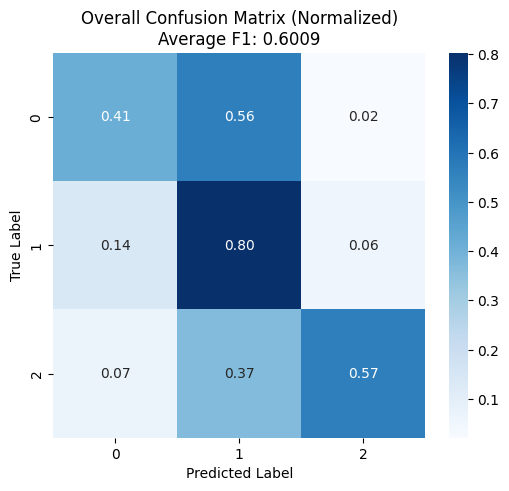


Cross-validation results
Fold F1s: [0.6025782688766114, 0.6090200183080402, 0.6173487292593327, 0.574561459255354]
Mean Macro F1: 0.6009
Std Macro F1: 0.0161


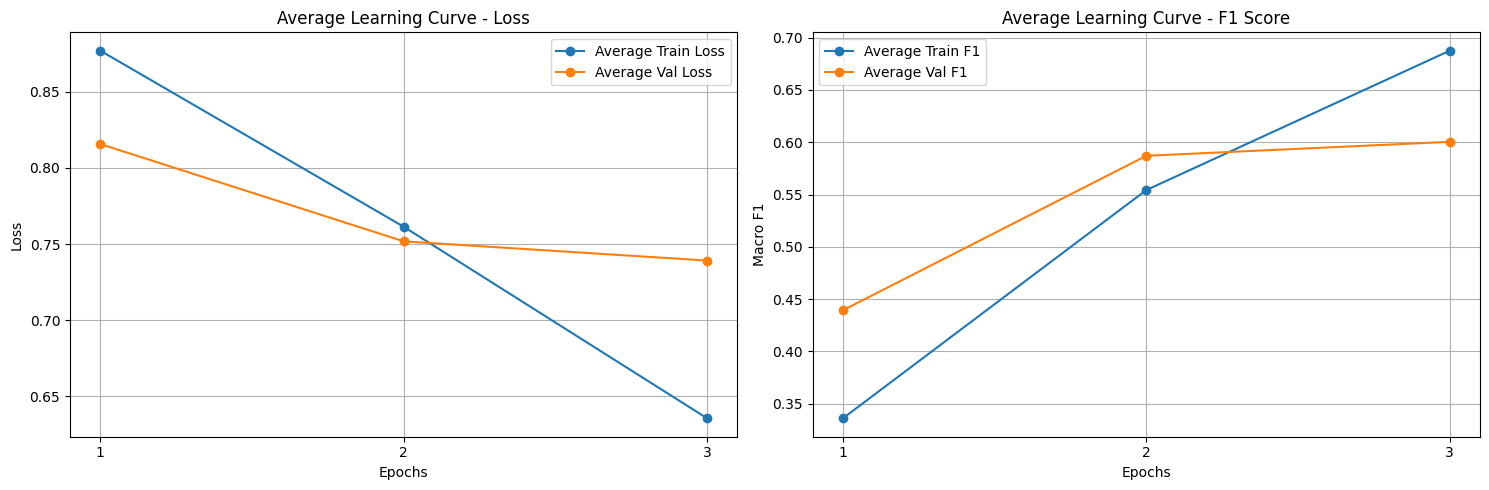

In [10]:

# ==========================================
#  Experiment 1
# ==========================================

n_splits = 4
num_epochs = 3 
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, # beacause as we saw at the token analysis there are many rows with larger that 512 tokens
        padding=True,
        max_length=512 # beacuse most of the tokens are grater that 512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



## Batch Size & Learning Rate Tuning
After establishing the baseline model, the next experiments focused on hyperparameter tuning. In particular, different batch sizes and learning rates were tested in order to examine their effect on training stability and validation performance. These parameters are important because they directly influence how fast and how effectively the model learns during fine-tuning.

### Experiment 2 
*Experimental Configuration*

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 4
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/4


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/638 [00:00<?, ?it/s]

...

Epoch 1: Train Loss 0.8713 | Val Loss 0.8009 | Val F1 0.4331


Fold 4 Epoch 2:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7324 | Val Loss 0.7753 | Val F1 0.5763


Fold 4 Epoch 3:   0%|          | 0/638 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.5914 | Val Loss 0.8075 | Val F1 0.5789

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5958 ± 0.0167

Fold execution times:
Fold 1: 11.44 minutes
Fold 2: 11.44 minutes
Fold 3: 11.43 minutes
Fold 4: 11.44 minutes

Total time for all 4 folds: 45.75 minutes
Average time per fold: 11.44 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.61      0.39      0.48      1041
           1       0.69      0.82      0.75      2009
           2       0.58      0.55      0.56       352

    accuracy                           0.66      3402
   macro avg       0.62      0.59      0.60      3402
weighted avg       0.65      0.66      0.65      3402



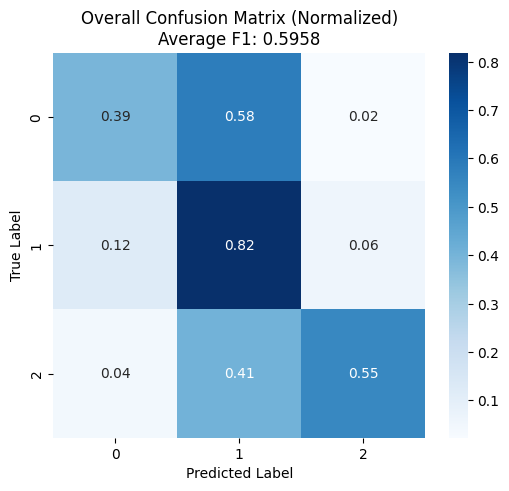


Cross-validation results
Fold F1s: [0.579485515133049, 0.6111660260007307, 0.6138368673579941, 0.5788830962251932]
Mean Macro F1: 0.5958
Std Macro F1: 0.0167


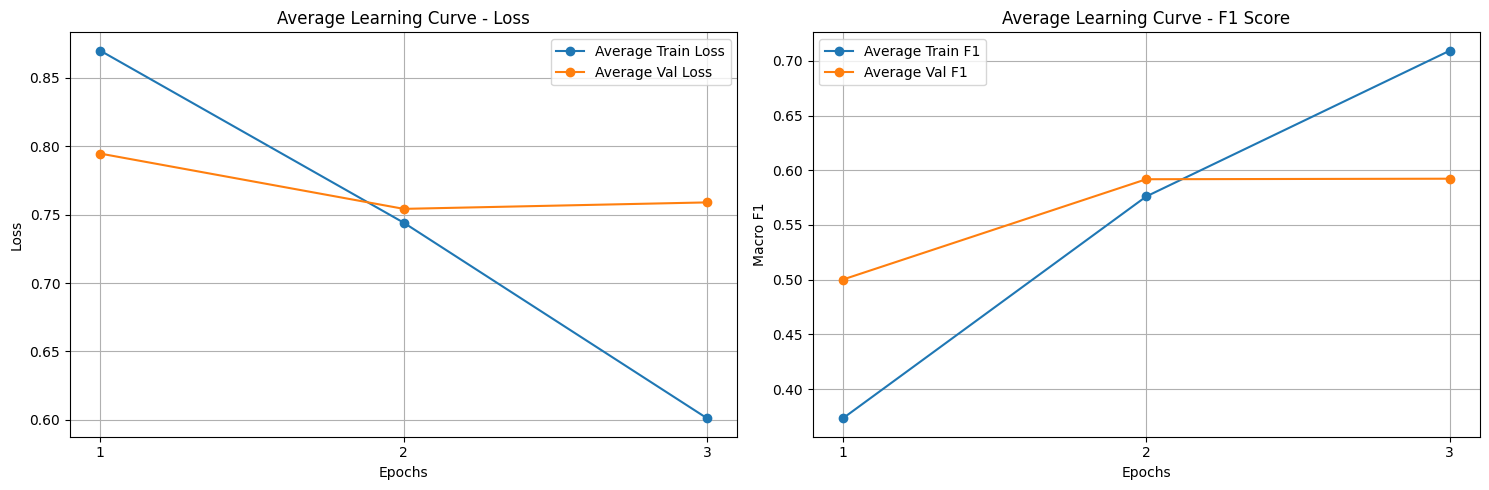

In [8]:

# ==========================================
#  Experiment 2
# ==========================================

n_splits = 4
num_epochs = 3
batch_size = 4
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, # because as we saw at the token analysis there are many rows with larger that 512 tokens
        padding=True,
        max_length=512 # because most of the tokens are greater that 512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Experiment 3
*Experimental Configuration*

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8766 | Val Loss 0.7972 | Val F1 0.5522


...

Epoch 1: Train Loss 0.8832 | Val Loss 0.8073 | Val F1 0.3843


Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7442 | Val Loss 0.7810 | Val F1 0.5755


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.5916 | Val Loss 0.8089 | Val F1 0.5888

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5869 ± 0.0341

Fold execution times:
Fold 1: 9.72 minutes
Fold 2: 9.70 minutes
Fold 3: 9.72 minutes
Fold 4: 9.71 minutes

Total time for all 4 folds: 38.86 minutes
Average time per fold: 9.71 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.61      0.37      0.46      1041
           1       0.68      0.84      0.75      2009
           2       0.60      0.53      0.56       352

    accuracy                           0.66      3402
   macro avg       0.63      0.58      0.59      3402
weighted avg       0.65      0.66      0.64      3402



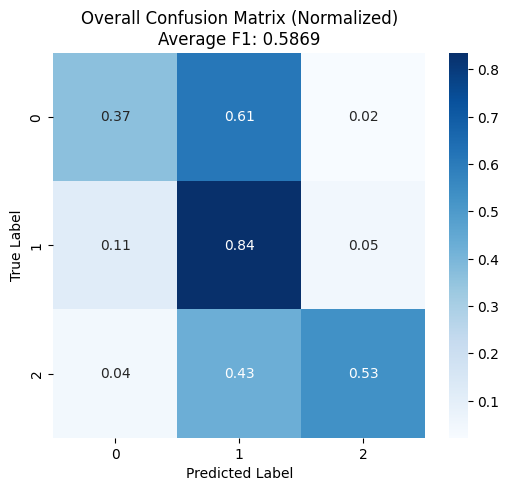


Cross-validation results
Fold F1s: [0.6063721813806874, 0.5313009231790958, 0.6212774927851116, 0.5888362451379759]
Mean Macro F1: 0.5869
Std Macro F1: 0.0341


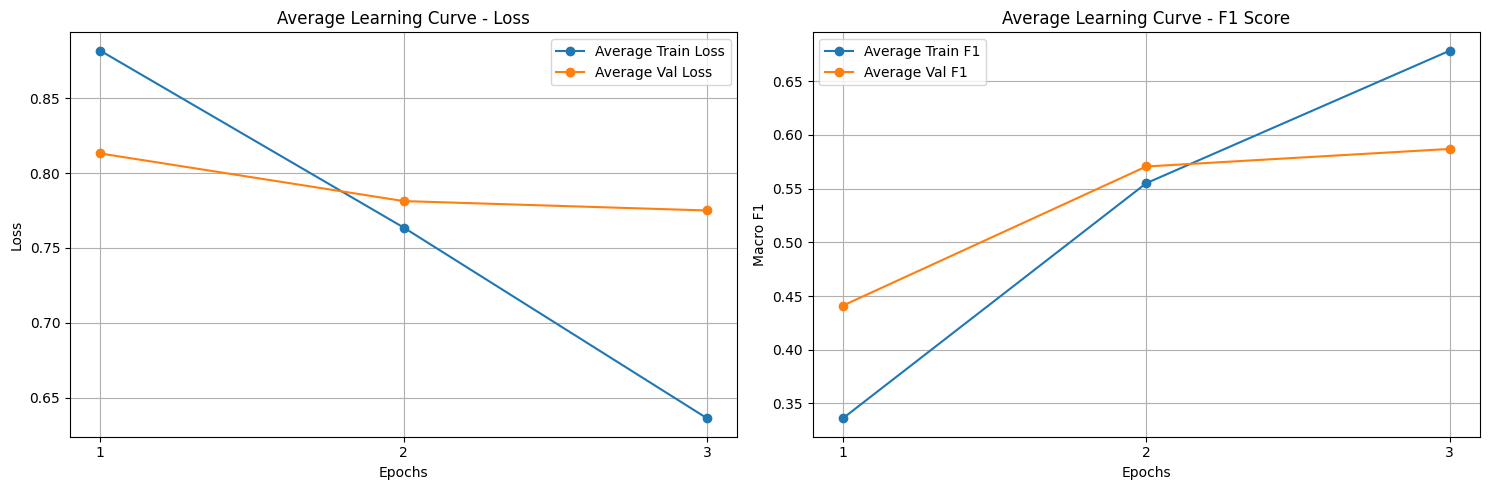

In [22]:

# ==========================================
#  Experiment 3
# ==========================================

n_splits = 4
num_epochs = 3 
batch_size = 8
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Experiment 4 
*Experimental Configuration*

- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 16
- **Learning rate:** 3 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score



 Starting Fold 1/4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8916 | Val Loss 0.8578 | Val F1 0.2827


...

Epoch 1: Train Loss 0.8796 | Val Loss 0.8214 | Val F1 0.4500


Fold 4 Epoch 2:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7570 | Val Loss 0.7885 | Val F1 0.5606


Fold 4 Epoch 3:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6266 | Val Loss 0.7879 | Val F1 0.5605

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5815 ± 0.0272

Fold execution times:
Fold 1: 8.73 minutes
Fold 2: 8.71 minutes
Fold 3: 8.72 minutes
Fold 4: 8.73 minutes

Total time for all 4 folds: 34.90 minutes
Average time per fold: 8.72 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.60      0.32      0.42      1041
           1       0.68      0.84      0.75      2009
           2       0.57      0.58      0.58       352

    accuracy                           0.65      3402
   macro avg       0.62      0.58      0.58      3402
weighted avg       0.64      0.65      0.63      3402



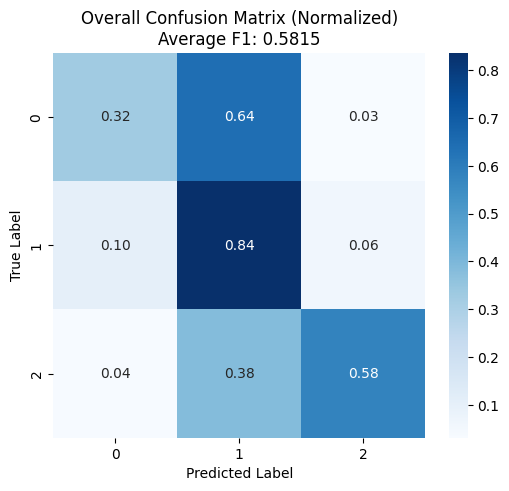


Cross-validation results
Fold F1s: [0.5949347227884545, 0.5511572621620751, 0.6193251666165488, 0.5606224991107318]
Mean Macro F1: 0.5815
Std Macro F1: 0.0272


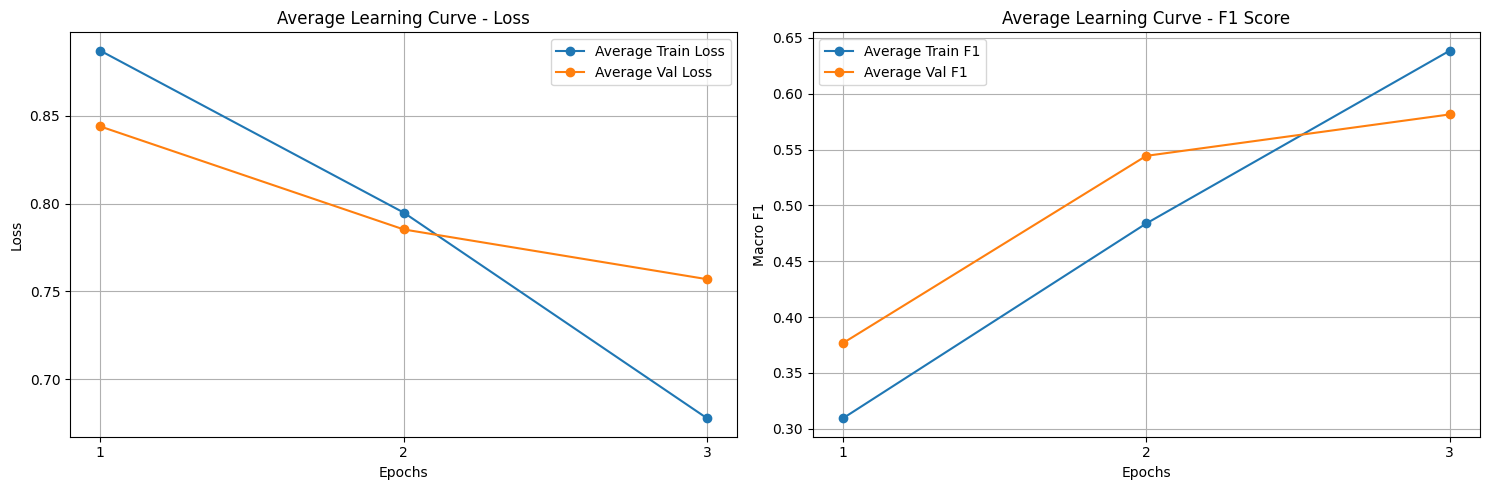

In [23]:

# ==========================================
#  Experiment 4
# ==========================================

n_splits = 4
num_epochs = 3
batch_size = 16
learning_rate = 3e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Conclusion
The experiments that modified the learning rate and batch size did not outperform the 
baseline BERT configuration.

##  Handling Class Imbalance with Weighted Loss


Since the dataset is imbalanced, and the confusion matrices from the previous experiments showed that the model often confused the minority classes, class-weighted cross-entropy loss was introduced. This approach gives higher importance to underrepresented classes by penalizing their misclassification more strongly.

Different class-weight combinations were tested, including weights based on the actual class proportions and manually selected weights. The manual weights performed better overall. Below, two representative tests are presented using the weight combinations [1.6, 1.0, 1.5] and [1.4, 1.0, 1.5]. The combination [1.3, 1.0, 1.5] was kept for the later experiments with more epochs and warm-up steps, because it achieved the best performance among the tested weight configurations.

#### Experiment 5
- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score
- **Class weights:** [1.6, 1, 1.5]



 Starting Fold 1/4
Class weights: [1.6 1.  1.5]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.9505 | Val Loss 0.9031 | Val F1 0.3289


...

Epoch 1: Train Loss 0.9382 | Val Loss 0.8734 | Val F1 0.5028


Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.8153 | Val Loss 0.8317 | Val F1 0.5593


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6726 | Val Loss 0.8036 | Val F1 0.5919

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5940 ± 0.0069

Fold execution times:
Fold 1: 9.20 minutes
Fold 2: 9.20 minutes
Fold 3: 9.20 minutes
Fold 4: 9.21 minutes

Total time for all 4 folds: 36.81 minutes
Average time per fold: 9.20 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.55      0.40      0.46      1041
           1       0.69      0.77      0.73      2009
           2       0.56      0.63      0.59       352

    accuracy                           0.64      3402
   macro avg       0.60      0.60      0.59      3402
weighted avg       0.63      0.64      0.63      3402



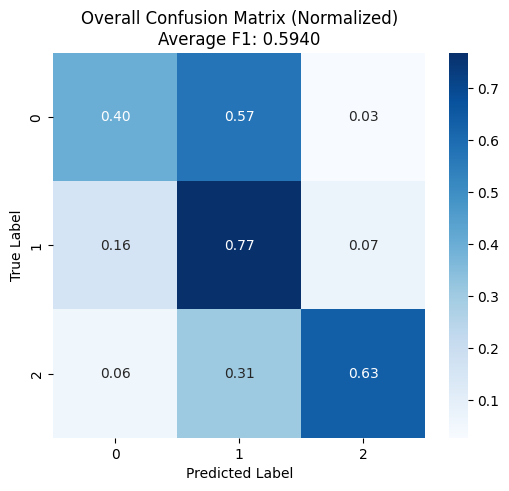


Cross-validation results
Fold F1s: [0.5863020103799015, 0.5927537326007086, 0.6050993524771241, 0.5918698260851881]
Mean Macro F1: 0.5940
Std Macro F1: 0.0069


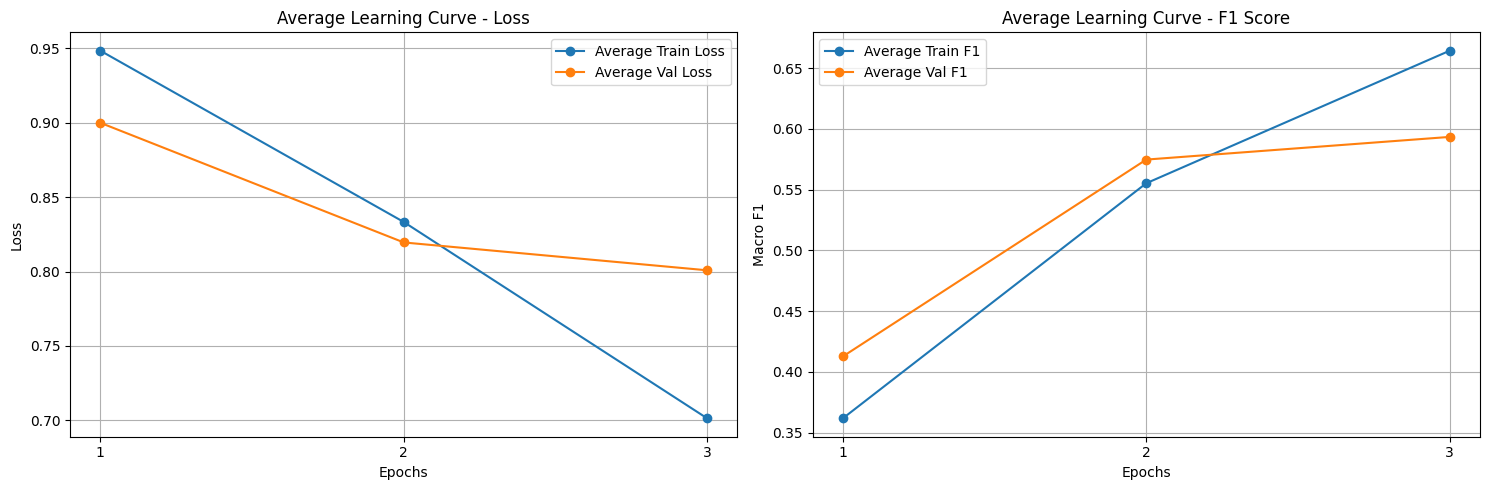

In [9]:

# ==========================================
#  Experiment 5 
# ==========================================

n_splits = 4
num_epochs = 3 
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512  
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
    # class weights
    class_weights = torch.tensor([1.6, 1, 1.5] , dtype=torch.float).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())

    # model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    # for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification and class weights
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)

            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



#### Experiment 6
- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score
- **Class weights:**  [1.4, 1, 1.5]


 Starting Fold 1/4
Class weights: [1.4 1.  1.5]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.9501 | Val Loss 0.8866 | Val F1 0.4677


...

Epoch 1: Train Loss 0.9353 | Val Loss 0.8600 | Val F1 0.5204


Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7977 | Val Loss 0.8150 | Val F1 0.5663


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6622 | Val Loss 0.8183 | Val F1 0.5912

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5964 ± 0.0080

Fold execution times:
Fold 1: 9.25 minutes
Fold 2: 9.25 minutes
Fold 3: 9.24 minutes
Fold 4: 9.27 minutes

Total time for all 4 folds: 37.02 minutes
Average time per fold: 9.25 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.55      0.41      0.47      1041
           1       0.69      0.78      0.73      2009
           2       0.59      0.58      0.58       352

    accuracy                           0.65      3402
   macro avg       0.61      0.59      0.60      3402
weighted avg       0.64      0.65      0.64      3402



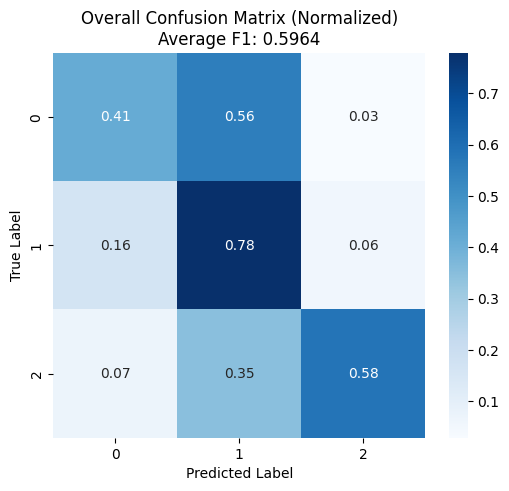


Cross-validation results
Fold F1s: [0.5865487544875189, 0.6070746379398976, 0.6007436581547746, 0.591239622552293]
Mean Macro F1: 0.5964
Std Macro F1: 0.0080


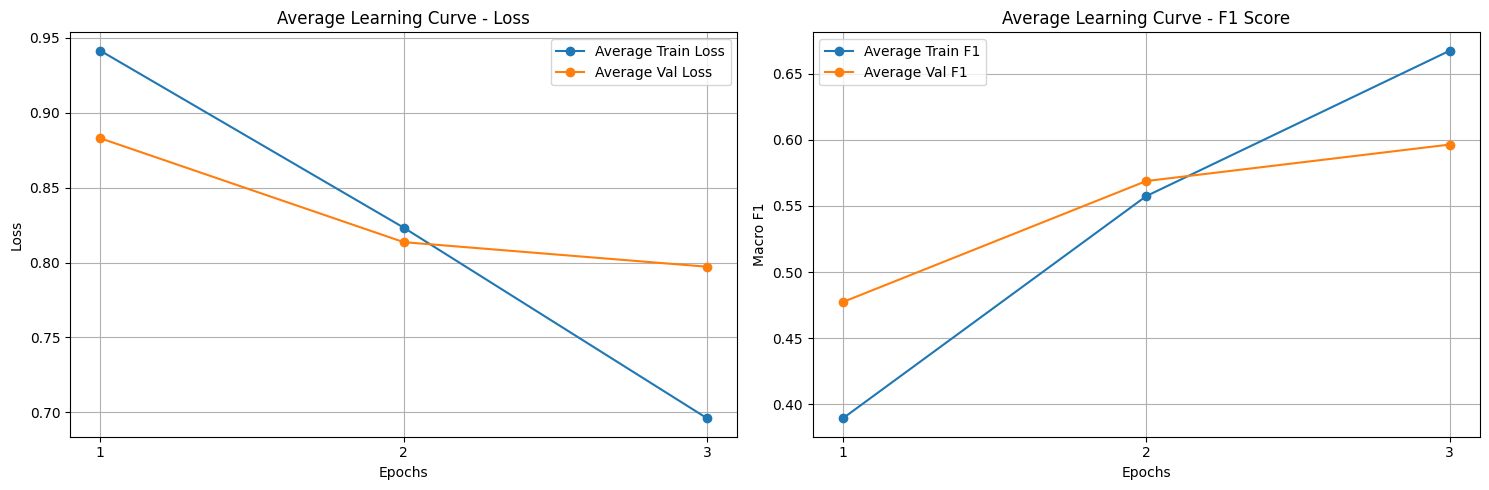

In [15]:

# ==========================================
#  Experiment 6
# ==========================================

n_splits = 4
num_epochs = 3 
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
    # class weights
    class_weights = torch.tensor([1.4, 1, 1.5] , dtype=torch.float).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())

    # model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    # for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification and class weights
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)

            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Conclusion
The experiments with weighted cross-entropy loss did not outperform the baseline model in 
terms of macro F1-score, but they produced important changes in the confusion matrix. More 
specifically, by assigning higher weights to the minority classes, the model became more 
sensitive to these classes and was able to identify them more effectively. This indicates 
that the weighted loss function helped the model focus more on underrepresented categories.

## Handling Long Inputs with Striding Window
#### Experiment 7
- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with warm-up steps
- **Primary evaluation metric:** Macro F1-score
- **Striding window**


 Starting Fold 1/4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/466 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8634 | Val Loss 0.7736 | Val F1 0.4613


...

Epoch 1: Train Loss 0.8310 | Val Loss 0.7799 | Val F1 0.5324


Fold 4 Epoch 2:   0%|          | 0/472 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.7270 | Val Loss 0.7567 | Val F1 0.5655


Fold 4 Epoch 3:   0%|          | 0/472 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.5988 | Val Loss 0.7612 | Val F1 0.5682

 Overall Cross Validation Results (Per Sample) 

Average Validation F1 Score: 0.5835 ± 0.0169

 Overall Classification Report (Out-Of-Fold):
              precision    recall  f1-score   support

           0       0.57      0.35      0.44      1041
           1       0.68      0.83      0.75      2009
           2       0.60      0.55      0.57       352

    accuracy                           0.65      3402
   macro avg       0.62      0.58      0.58      3402
weighted avg       0.64      0.65      0.63      3402



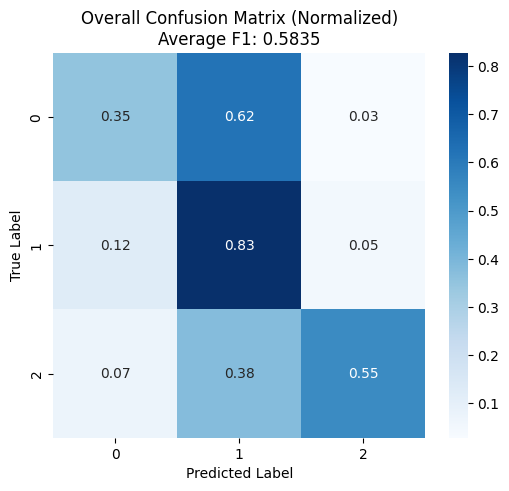


Cross-validation results
Fold F1s: [0.5930796335447498, 0.5663109829621588, 0.6062782190313918, 0.5681718828357617]
Mean Macro F1: 0.5835
Std Macro F1: 0.0169


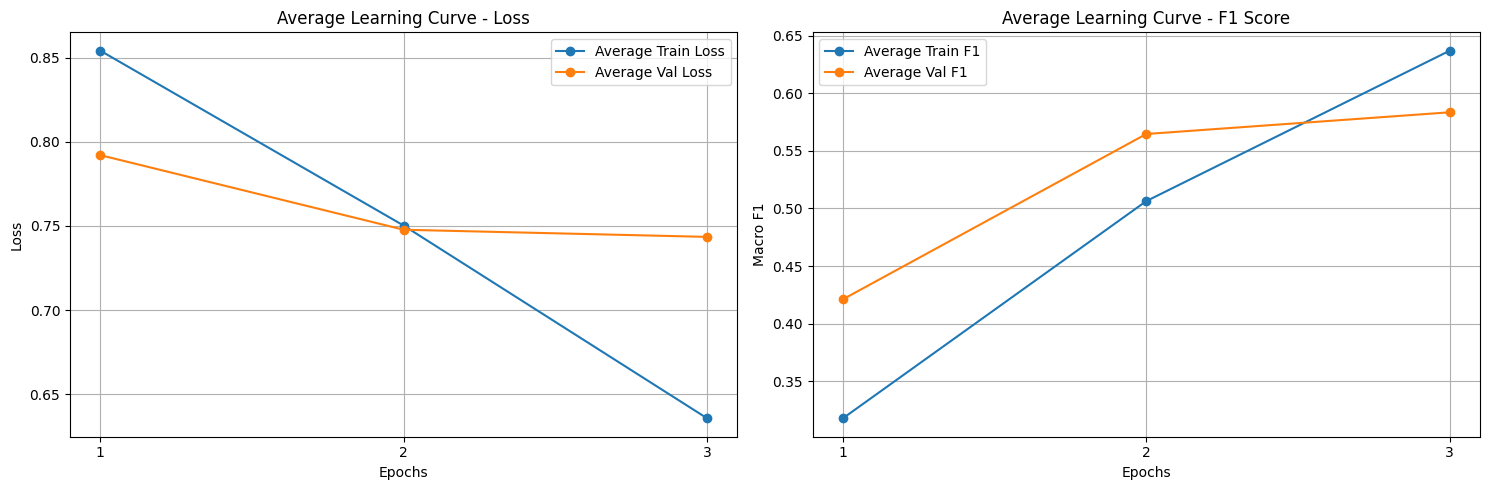

In [9]:
from collections import Counter


# ==========================================
#  Experiment 7
# ==========================================

n_splits = 4
num_epochs = 3 
batch_size = 8
learning_rate = 2e-5
max_length = 512
stride = 128  # lenght of stride window

# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
oof_preds = []
oof_labels = []

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# ==========================================
#  Cross-Validation Loop
# ==========================================

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx].reset_index(drop=True)
    df_val_fold = df_train.iloc[val_idx].reset_index(drop=True)

  # --- Tokenization with Sliding Window ---
    # If an interview answer is longer than max_length,
    # it is split into multiple overlapping chunks.
    # truncation="only_second" means that only the answer is split/truncated,
    # while the question remains the same for every chunk.
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation="only_second",
        padding="max_length",
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True
    )
    
     # Maps each generated chunk back to the original training sample.
    # This is needed because one sample can produce multiple chunks.
    train_sample_map = train_encodings.pop("overflow_to_sample_mapping")
     # Each chunk gets the label of its original sample.

    train_labels_expanded = [df_train_fold["labels"].iloc[i] for i in train_sample_map]

    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation="only_second",
        padding="max_length",
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True
    )
    # Keeps track of which validation sample each chunk belongs to.
    # Later, chunk predictions will be combined back into sample predictions.
    val_sample_map = val_encodings.pop("overflow_to_sample_mapping")

    # --- Datasets and Loaders ---
    train_dataset = ClarityDataset(train_encodings, train_labels_expanded)
    val_dataset = ClarityDataset(val_encodings, [df_val_fold["labels"].iloc[i] for i in val_sample_map])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # --- Model Setup ---
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    loss_fn = torch.nn.CrossEntropyLoss()

    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=int(0.1 * num_training_steps),  
        num_training_steps=num_training_steps
    )

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []

    # --- Training Loop ---
    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        train_preds, train_labels = [], []

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            
            loss.backward()
            optimizer.step()
            lr_scheduler.step()

            total_train_loss += loss.item()
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        # --- Validation Loop ---
        model.eval()
        total_val_loss = 0
        val_chunk_preds = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels)
                total_val_loss += loss.item()
                val_chunk_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())

         # --- Aggregate: Chunk level -> Sample level ---
        # The model predicts one label for each chunk.
        # Since one original sample may have many chunks,
        # we group all chunk predictions that belong to the same sample.
        sample_pred_map = {}
        for chunk_idx, sample_idx in enumerate(val_sample_map):
            sample_pred_map.setdefault(sample_idx, []).append(val_chunk_preds[chunk_idx])
        # Final prediction for each sample is decided by majority vote
        # over its chunk predictions.
        final_preds = [Counter(v).most_common(1)[0][0] for v in sample_pred_map.values()]
        final_labels = [df_val_fold["labels"].iloc[i] for i in sample_pred_map.keys()]
        # True labels at original sample level.

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        # Train F1 is chunk-level, validation F1 is sample-level.

        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        avg_val_f1 = f1_score(final_labels, final_preds, average="macro")

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = final_preds
            best_labels_fold = final_labels

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)

    del model, optimizer
    torch.cuda.empty_cache()

# ==========================================
#  OVERALL RESULTS & PLOTS
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results (Per Sample) ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)
print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\n Overall Classification Report (Out-Of-Fold):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)

### Conclusion
The striding-window experiment was introduced in order to handle longer question--answer 
pairs more effectively. Instead of truncating the input directly to BERT's maximum sequence 
length, the text was split into overlapping segments using a maximum length of 512 tokens 
and a stride of 128 tokens. The goal was to preserve more contextual information from long 
inputs and examine whether this additional context could improve classification performance.

However, the striding-window approach did not outperform the baseline model.

## Epoch Experiments
Additional experiments were conducted by increasing the number of training epochs. The goal was to examine whether the model could benefit from longer training or whether additional epochs would lead to overfitting. This was evaluated by comparing the training and validation losses, as well as the validation macro F1-score across epochs.


#### Experiment 8
- **Number of folds:** 4
- **Number of epochs:** 4
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Learning rate scheduler:** Linear scheduler with no warm-up steps
- **Primary evaluation metric:** Macro F1-score



 Starting Fold 1/4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.8909 | Val Loss 0.8240 | Val F1 0.4925


...

Epoch 2: Train Loss 0.7794 | Val Loss 0.7603 | Val F1 0.5600


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6412 | Val Loss 0.8205 | Val F1 0.5515


Fold 4 Epoch 4:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 4: Train Loss 0.5141 | Val Loss 0.8329 | Val F1 0.5943

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5983 ± 0.0216

Fold execution times:
Fold 1: 13.01 minutes
Fold 2: 13.00 minutes
Fold 3: 13.00 minutes
Fold 4: 13.00 minutes

Total time for all 4 folds: 52.01 minutes
Average time per fold: 13.00 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.59      0.40      0.48      1041
           1       0.69      0.83      0.75      2009
           2       0.63      0.52      0.57       352

    accuracy                           0.66      3402
   macro avg       0.64      0.58      0.60      3402
weighted avg       0.65      0.66      0.65      3402



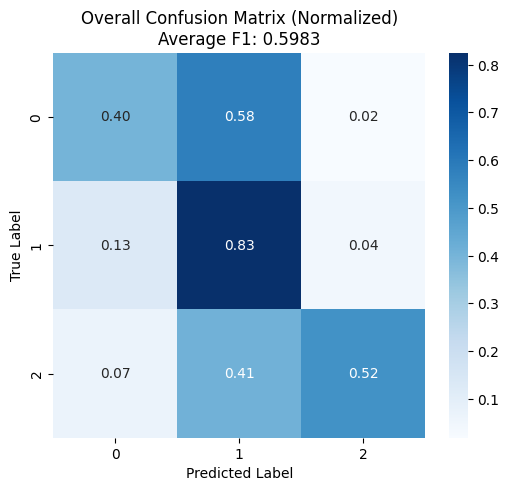


Cross-validation results
Fold F1s: [0.6168059083747593, 0.5644531709709413, 0.6174818788034485, 0.594295689936935]
Mean Macro F1: 0.5983
Std Macro F1: 0.0216


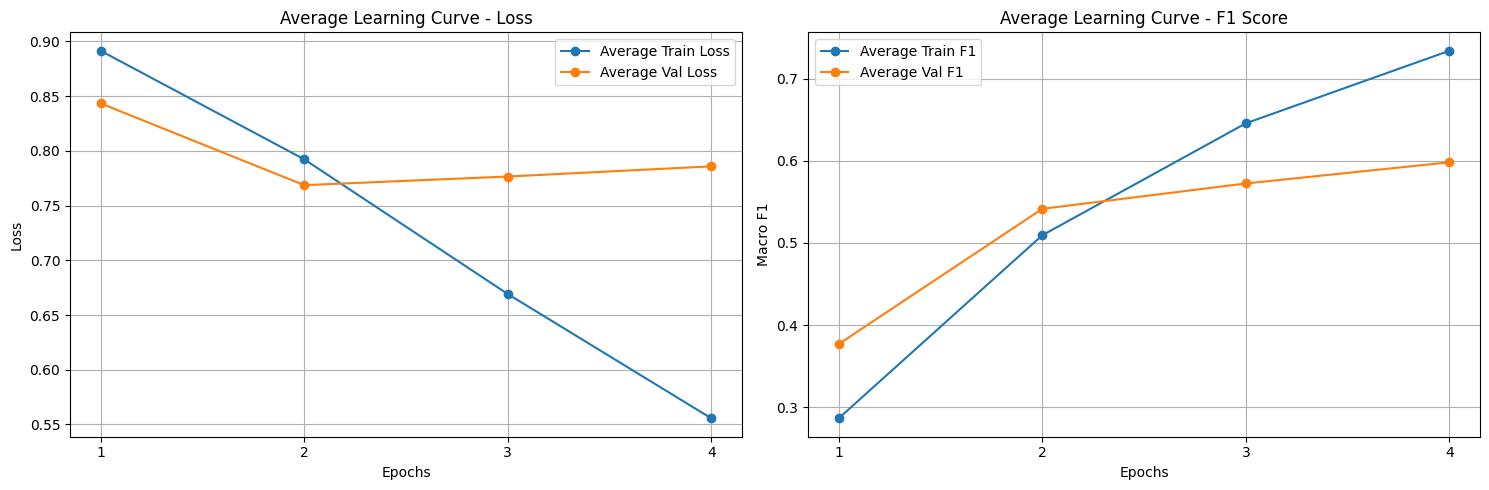

In [10]:

# ==========================================
#  Experiment 8
# ==========================================

n_splits = 4
num_epochs = 4 
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
# model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
# for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification
    loss_fn = torch.nn.CrossEntropyLoss()
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)
           
            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Conclusion
In this setup, the number of epochs was increased 
from 3 to 4, while the batch size and learning rate remained the same as in the baseline 
configuration.
Although the model achieved a mean macro F1-score of 0.5983, which is very close to the 
baseline score of 0.6009, it did not manage to outperform the baseline. This suggests that 
the additional training epoch did not provide a clear improvement in generalization. Instead, 
the model appears to start overfitting, as it learns the training data more strongly without 
achieving better validation performance.



#### Experiment 9
- **Number of folds:** 4
- **Number of epochs:** 4
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Class weights:** [1.3, 1.0, 1.5]
- **Learning rate scheduler:** Linear scheduler 
- **Primary evaluation metric:** Macro F1-score



 Starting Fold 1/4
Class weights: [1.3 1.  1.5]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 1: Train Loss 0.9458 | Val Loss 0.8734 | Val F1 0.4279


...

Epoch 2: Train Loss 0.8382 | Val Loss 0.8016 | Val F1 0.5686


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6942 | Val Loss 0.8250 | Val F1 0.5707


Fold 4 Epoch 4:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 4: Train Loss 0.5726 | Val Loss 0.8476 | Val F1 0.5904

 Overall Cross Validation Results  

Average Validation F1 Score: 0.5981 ± 0.0063

Fold execution times:
Fold 1: 12.26 minutes
Fold 2: 12.25 minutes
Fold 3: 12.25 minutes
Fold 4: 12.25 minutes

Total time for all 4 folds: 49.01 minutes
Average time per fold: 12.25 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.56      0.41      0.48      1041
           1       0.69      0.78      0.74      2009
           2       0.59      0.58      0.58       352

    accuracy                           0.65      3402
   macro avg       0.61      0.59      0.60      3402
weighted avg       0.64      0.65      0.64      3402



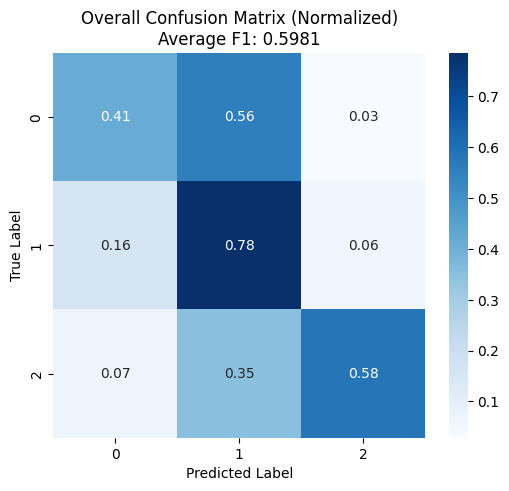


Cross-validation results
Fold F1s: [0.6048674114674781, 0.59338574546452, 0.6035862285862287, 0.5904320287333918]
Mean Macro F1: 0.5981
Std Macro F1: 0.0063


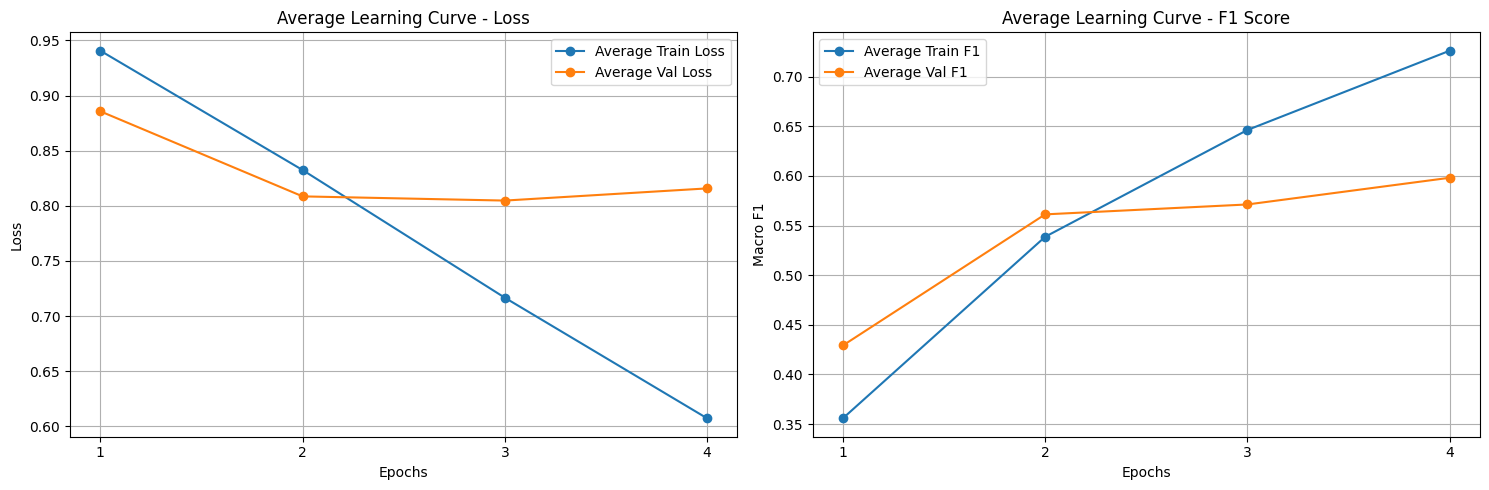

In [10]:

# ==========================================
#  Experiment 9
# ==========================================

n_splits = 4
num_epochs = 4
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, 
        padding=True,
        max_length=512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
    # class weights
    class_weights = torch.tensor([1.3, 1, 1.5] , dtype=torch.float).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())

    # model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    # for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification and class weights
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=0,  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)

            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Conclusion

In Experiment 9, class weights were combined with an increased number of training epochs to examine whether the model could better handle class imbalance while also benefiting from additional training. The model achieved a mean macro F1-score of 0.5981 with a low standard deviation of 0.0063, showing stable performance across the cross-validation folds.

Although this result was slightly lower than the baseline score of 0.6009, the low standard deviation indicates that the model performed consistently across folds. In addition, the use of class weights helped the model distinguish the minority classes more effectively, as observed in the confusion matrices.

However, adding one more epoch did not improve the overall mean performance compared to the baseline. In several folds, the validation loss increased in the later epochs while the training loss continued to decrease, suggesting signs of overfitting. Nevertheless, this configuration produced the lowest standard deviation among all experiments, indicating the most stable behavior across the tested configurations. 

## Learning Rate Warm-Up Experiment

In this final experiment, warm-up steps were added to the linear learning rate scheduler. This configuration was based on the class-weight setup from Experiment 9, which showed stable performance and improved sensitivity toward the minority classes, although its macro F1-score was slightly lower than the baseline. The aim was to examine whether gradually increasing the learning rate at the beginning of training could make fine-tuning more stable and further improve validation performance.

#### Experiment 10
- **Number of folds:** 4
- **Number of epochs:** 3
- **Batch size:** 8
- **Learning rate:** 2 × 10⁻⁵
- **Optimizer:** AdamW
- **Loss function:** Cross-entropy loss
- **Class weights:** [1.3, 1.0, 1.5]
- **Learning rate scheduler:** Linear scheduler with warm-up steps
- **Primary evaluation metric:** Macro F1-score


 Starting Fold 1/4
Class weights: [1.3 1.  1.5]


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 Epoch 1:   0%|          | 0/319 [00:00<?, ?it/s]

...

Epoch 1: Train Loss 0.9472 | Val Loss 0.8652 | Val F1 0.4404


Fold 4 Epoch 2:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 2: Train Loss 0.8184 | Val Loss 0.8232 | Val F1 0.5844


Fold 4 Epoch 3:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 3: Train Loss 0.6709 | Val Loss 0.8294 | Val F1 0.5796

 Overall Cross Validation Results  

Average Validation F1 Score: 0.6041 ± 0.0162

Fold execution times:
Fold 1: 8.91 minutes
Fold 2: 8.90 minutes
Fold 3: 8.89 minutes
Fold 4: 8.90 minutes

Total time for all 4 folds: 35.62 minutes
Average time per fold: 8.90 minutes

 Overall Classification Report (Out-Of-Fold Predictions):
              precision    recall  f1-score   support

           0       0.55      0.45      0.49      1041
           1       0.69      0.77      0.73      2009
           2       0.63      0.56      0.59       352

    accuracy                           0.65      3402
   macro avg       0.62      0.59      0.61      3402
weighted avg       0.64      0.65      0.64      3402



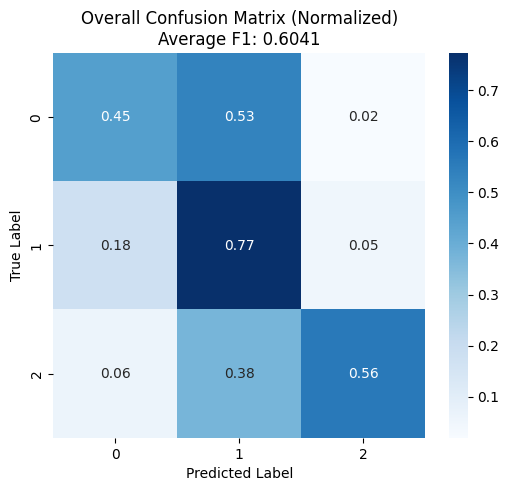


Cross-validation results
Fold F1s: [0.5928994364135064, 0.6143511433473385, 0.624905913541984, 0.5843764226068844]
Mean Macro F1: 0.6041
Std Macro F1: 0.0162


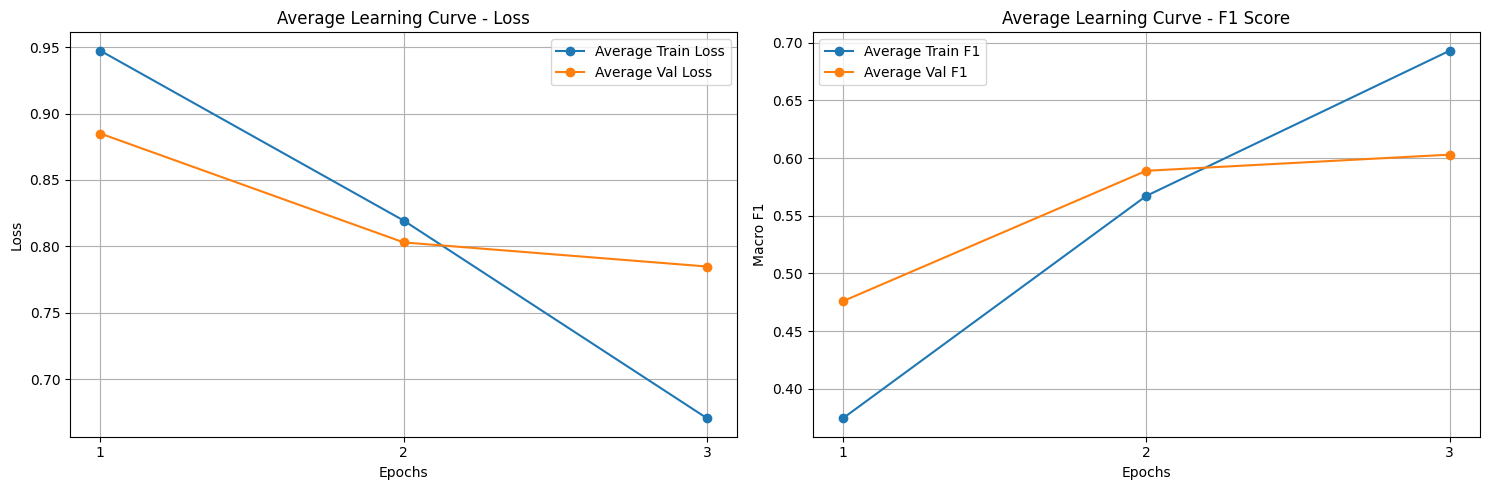

In [9]:

# ==========================================
#  Experiment 10
# ==========================================

n_splits = 4
num_epochs = 3 
batch_size = 8
learning_rate = 2e-5


# Metrics storage
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
fold_results = []
# Out-Of-Fold predictions
oof_preds = []
oof_labels =[]

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_times = []
experiment_start_time = time.time()
# ==========================================
#  Cross-Validation Loop
# ==========================================
# Loop over folds

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train["labels"])):
    fold_start_time = time.time()
    print(f"\n Starting Fold {fold + 1}/{n_splits}")
    
    df_train_fold = df_train.iloc[train_idx]
    df_val_fold = df_train.iloc[val_idx]
#Tokenizer
    train_encodings = tokenizer(
        list(df_train_fold["question"]),
        list(df_train_fold["interview_answer"]),
        truncation=True, # because as we saw at the token analysis there are many rows with larger that 512 tokens
        padding=True,
        max_length=512 # because most of the tokens are greater that 512 
    )
    val_encodings = tokenizer(
        list(df_val_fold["question"]),
        list(df_val_fold["interview_answer"]),
        truncation=True,
        padding=True,
        max_length=512
    )
 
    train_dataset = ClarityDataset(train_encodings, df_train_fold["labels"].tolist())
    val_dataset = ClarityDataset(val_encodings, df_val_fold["labels"].tolist())

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True 
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False # no shuffle here
    )
    # class weights
    class_weights = torch.tensor([1.3, 1, 1.5] , dtype=torch.float).to(device)
    print("Class weights:", class_weights.detach().cpu().numpy())

    # model
    model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=3)
    # for 2 gpus
    if device_manager.use_data_parallel:
        model = torch.nn.DataParallel(model)
    model.to(device)
   #optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate)
# Cross-entropy loss for multiclass classification and class weights
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
# Scheduler for gradually decreasing the learning rate
    num_training_steps = num_epochs * len(train_loader)
    lr_scheduler = get_scheduler(
        name="linear", 
        optimizer=optimizer, 
        num_warmup_steps=int(0.1 * num_training_steps),  
        num_training_steps=num_training_steps
    )

    # Store training and validation loss/F1 for each epoch in the current fold

    fold_train_loss, fold_val_loss = [], []
    fold_train_f1, fold_val_f1 = [], []
    # Keep the best validation F1 score for this fold

    best_f1_fold = 0
    best_preds_fold, best_labels_fold = [], []
    # Loop over epochs
    for epoch in range(num_epochs):
        model.train()     # Set the model to training mode
        total_train_loss = 0     # Reset training loss for each epoch

        train_preds, train_labels = [], []     # Store training predictions and labels for F1 calculation

        # Training loop over batches

        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            
            optimizer.zero_grad()         # Clear previous gradients
           
            # Move batch data to device 

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            # Forward pass
            outputs = model(input_ids, attention_mask=attention_mask)

            loss = loss_fn(outputs.logits, labels) # Compute loss
            loss.backward() # Backpropagation            
            optimizer.step()# Update model parameters
            lr_scheduler.step()# Update learning rate

            total_train_loss += loss.item() # Add batch loss to total training loss
            # Store predictions and true labels for this batch
            train_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        # Compute average training loss for the epoch
        avg_train_loss = total_train_loss / len(train_loader)
        # Compute training macro F1 score for the epoch
        avg_train_f1 = f1_score(train_labels, train_preds, average="macro")
        
        # Set the model to evaluation mode

        model.eval()
        total_val_loss = 0 # Reset validation loss for this epoch
        val_preds, val_labels = [], [] # Store validation predictions and labels for F1 calculation
       
        # Validation loop (no gradient computation)
        with torch.no_grad():
            for batch in val_loader:
                # Move batch data to device
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                # Forward pass
                outputs = model(input_ids, attention_mask=attention_mask)
                loss = loss_fn(outputs.logits, labels) # Compute validation loss

                total_val_loss += loss.item()# Add batch loss to total validation loss
                # Store predictions and true labels
                val_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_f1 = f1_score(val_labels, val_preds, average="macro")
        
        # Save training/validation metrics for this epoch

        fold_train_loss.append(avg_train_loss)
        fold_val_loss.append(avg_val_loss)
        fold_train_f1.append(avg_train_f1)
        fold_val_f1.append(avg_val_f1)

        if avg_val_f1 > best_f1_fold:
            best_f1_fold = avg_val_f1
            best_preds_fold = val_preds
            best_labels_fold = val_labels
        
            

        print(f"Epoch {epoch+1}: Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | Val F1 {avg_val_f1:.4f}")

    history['train_loss'].append(fold_train_loss)
    history['val_loss'].append(fold_val_loss)
    history['train_f1'].append(fold_train_f1)
    history['val_f1'].append(fold_val_f1)
    fold_results.append(best_f1_fold)
    oof_preds.extend(best_preds_fold)
    oof_labels.extend(best_labels_fold)
    
    fold_time = time.time() - fold_start_time
    fold_times.append(fold_time)
    del model, optimizer
    torch.cuda.empty_cache()
# ==========================================
#  OVERALL RESULTS 
# ==========================================

print("\n" + "="*50)
print(" Overall Cross Validation Results  ")
print("="*50)

mean_f1 = np.mean(fold_results)
std_f1 = np.std(fold_results)

print(f"\nAverage Validation F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print("\nFold execution times:")
for i, fold_time in enumerate(fold_times):
    print(f"Fold {i+1}: {fold_time/60:.2f} minutes")

total_time = time.time() - experiment_start_time
mean_fold_time = np.mean(fold_times)

print(f"\nTotal time for all {n_splits} folds: {total_time/60:.2f} minutes")
print(f"Average time per fold: {mean_fold_time/60:.2f} minutes")

print("\n Overall Classification Report (Out-Of-Fold Predictions):")
print(classification_report(oof_labels, oof_preds))

plt.figure(figsize=(6, 5))
cm_overall = confusion_matrix(oof_labels, oof_preds, normalize='true')
sns.heatmap(cm_overall, annot=True, cmap='Blues', fmt='.2f')
plt.title(f"Overall Confusion Matrix (Normalized)\nAverage F1: {mean_f1:.4f}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_results = plot_cv_learning_curves(history, fold_results, num_epochs)



### Conclusion

Experiment 10 achieved the highest average macro F1-score, reaching 0.6041. This indicates that the combination of selected class weights and warm-up steps improved the average performance of the model compared to the baseline and to the previous class-weighted experiments. Although this configuration had a higher standard deviation than Experiment 9, it provided the best overall mean performance across the tested settings.

# Summary

| Experiment | Main Change | Average Macro F1 | Std |
|---|---|---:|---:|
| Experiment 1 | Baseline BERT model | 0.6009 | 0.0161 |
| Experiment 2 | Batch size = 4 | 0.5958 | 0.0167 |
| Experiment 3 | Learning rate = 3e-5 | 0.5869 | 0.0341 |
| Experiment 4 | Batch size = 16, learning rate = 3e-5 | 0.5815 | 0.0272 |
| Experiment 5 | Weighted loss: [1.6, 1.0, 1.5] | 0.5940 | 0.0069 |
| Experiment 6 | Weighted loss: [1.4, 1.0, 1.5] | 0.5964 | 0.0080 |
| Experiment 7 | Striding window | 0.5835 | 0.0169 |
| Experiment 8 | 4 epochs | 0.5983 | 0.0216 |
| Experiment 9 | 4 epochs + class weights [1.3, 1.0, 1.5] | 0.5981 | 0.0063 |
| Experiment 10 | Class weights + warm-up scheduler [1.3, 1.0, 1.5] | 0.6041 | 0.0162 |

Across all experiments, different strategies were tested in order to improve the macro F1-score of the BERT-based classifier. The baseline model provided the initial reference point, while the following experiments explored the effect of class weighting, adjusted loss functions, and learning-rate warm-up.

The best overall result was achieved by Experiment 10, with an average macro F1-score of 0.6041. This experiment combined the selected class weights with warm-up steps, which helped the model benefit more effectively from the weighted-loss setup.

Although Experiment 9 also achieved strong performance, Experiment 10 produced the highest mean macro F1-score across the tested configurations. For this reason, Experiment 10 was selected as the final model configuration.